<h1> FEMM (Finite Element Method Magnetics) </h1>

In [37]:
import torch
import numpy as np
import time
import meshio   

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Выбрано: {device}")

start = time.time()

#загрузка сетки
mesh = meshio.read("dipole2d.msh")

#координаты узлов
X_y = mesh.points[:, :2]

Выбрано: cuda



In [39]:
print(X_y)

[[-2.00000000e+00  0.00000000e+00]
 [-2.00000000e+00  3.50000000e+00]
 [ 2.00000000e+00  3.50000000e+00]
 [ 2.00000000e+00  5.00000000e-01]
 [ 5.00000000e+00  5.00000000e-01]
 [ 5.00000000e+00  6.50000000e+00]
 [-5.00000000e+00  6.50000000e+00]
 [-5.00000000e+00  0.00000000e+00]
 [-1.00000000e+00  5.00000000e-01]
 [ 1.00000000e+00  5.00000000e-01]
 [ 1.00000000e+00  2.50000000e+00]
 [-1.00000000e+00  2.50000000e+00]
 [ 6.00000000e+00  5.00000000e-01]
 [ 8.00000000e+00  5.00000000e-01]
 [ 6.00000000e+00  2.50000000e+00]
 [ 8.00000000e+00  2.50000000e+00]
 [-5.00000000e+01  0.00000000e+00]
 [ 5.00000000e+01  0.00000000e+00]
 [ 5.00000000e+01  5.00000000e+01]
 [-5.00000000e+01  5.00000000e+01]
 [-2.00000000e+00  8.75000000e-01]
 [-2.00000000e+00  1.75000000e+00]
 [-2.00000000e+00  2.62500000e+00]
 [-1.00000000e+00  3.50000000e+00]
 [-5.50470780e-12  3.50000000e+00]
 [ 1.00000000e+00  3.50000000e+00]
 [ 2.00000000e+00  2.50000000e+00]
 [ 2.00000000e+00  1.50000000e+00]
 [ 3.00000000e+00  5

In [40]:
all_triangles = []
all_triangle_tags = []
all_lines = []
all_line_tags = []

#теги 
physical_data = mesh.cell_data.get("gmsh:physical", [])

for i, cell_block in enumerate(mesh.cells):
    if cell_block.type == "triangle":
        all_triangles.append(cell_block.data)
        all_triangle_tags.append(physical_data[i])
            
    elif cell_block.type == "line":
        all_lines.append(cell_block.data)
        all_line_tags.append(physical_data[i])

#объединение в один массив
triangles = np.concatenate(all_triangles, axis=0)
triangle_tags = np.concatenate(all_triangle_tags, axis=0)
lines = np.concatenate(all_lines, axis=0)
line_tags = np.concatenate(all_line_tags, axis=0)

In [41]:
print(triangles, triangle_tags)

[[112 126 125]
 [  2 138 114]
 [117 138   2]
 ...
 [ 77 176 331]
 [211 170 311]
 [279 250 324]] [22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22
 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22
 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22
 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22
 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22
 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 23 23 23 23
 23 23 23 23 23 23 23 23 23 23 24 24 24 24 24 24 24 24 24 24 24 24 24 24
 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25
 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25
 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25
 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25
 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25
 25 25 25 25 25 25 25 25 25 

In [42]:
print(lines, line_tags)

[[  0  20]
 [ 20  21]
 [ 21  22]
 [ 22   1]
 [  1  23]
 [ 23  24]
 [ 24  25]
 [ 25   2]
 [  2  26]
 [ 26  27]
 [ 27   3]
 [  3  28]
 [ 28  29]
 [ 29   4]
 [  4  30]
 [ 30  31]
 [ 31  32]
 [ 32  33]
 [ 33  34]
 [ 34   5]
 [  5  35]
 [ 35  36]
 [ 36  37]
 [ 37  38]
 [ 38  39]
 [ 39  40]
 [ 40  41]
 [ 41  42]
 [ 42  43]
 [ 43   6]
 [  6  44]
 [ 44  45]
 [ 45  46]
 [ 46  47]
 [ 47  48]
 [ 48  49]
 [ 49   7]
 [  7  50]
 [ 50  51]
 [ 51   0]
 [ 16  60]
 [ 60  61]
 [ 61  62]
 [ 62  63]
 [ 63  64]
 [ 64  65]
 [ 65  66]
 [ 66  67]
 [ 67  68]
 [ 68  69]
 [ 69  70]
 [ 70   7]
 [  0  71]
 [ 71  72]
 [ 72  73]
 [ 73  74]
 [ 74  75]
 [ 75  76]
 [ 76  77]
 [ 77  78]
 [ 78  79]
 [ 79  80]
 [ 80  81]
 [ 81  82]
 [ 82  83]
 [ 83  17]
 [ 17  84]
 [ 84  85]
 [ 85  86]
 [ 86  87]
 [ 87  18]
 [ 18  88]
 [ 88  89]
 [ 89  90]
 [ 90  91]
 [ 91  92]
 [ 92  93]
 [ 93  94]
 [ 94  95]
 [ 95  96]
 [ 96  19]
 [ 19  97]
 [ 97  98]
 [ 98  99]
 [ 99 100]
 [100  16]] [28 28 28 28 28 28 28 28 28 28 28 28 28 28 28 28 28 2

<h2> Mesh Visualization </h2>

In [43]:
import matplotlib.pyplot as plt
import matplotlib.tri as tri

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


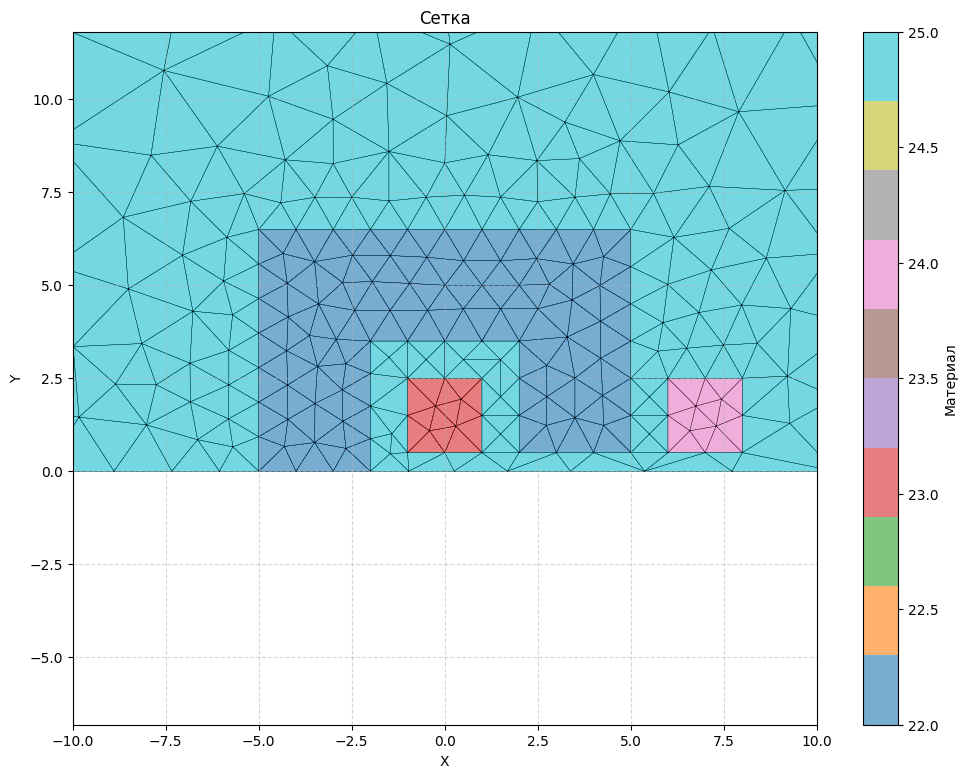

In [44]:
triang = tri.Triangulation(X_y[:, 0], X_y[:, 1], triangles)

plt.figure(figsize=(12, 9))

tpc = plt.tripcolor(triang, facecolors=triangle_tags, cmap='tab10', alpha=0.6)

plt.triplot(triang, color='black', lw=0.3)

plt.colorbar(tpc, label="Материал")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Сетка")

plt.axis('equal') 

plt.xlim(-10, 10)
plt.ylim(-5, 10)

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [45]:
mu_elem_np = np.ones(len(triangles))
mu_elem_np[triangle_tags == 22] = 1000.0

J_elem_np = np.zeros(len(triangles))
J_elem_np[triangle_tags == 23] = 1.0
J_elem_np[triangle_tags == 24] = -1.0 

In [46]:
print(mu_elem_np)
print(J_elem_np)

[1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.    1.    1.    1.    1.
    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
    1.    1.    1.    1.    1.    1.    1.    1.   

In [47]:
nodes = torch.tensor(X_y, dtype=torch.float32, device=device)
elements = torch.tensor(triangles, dtype=torch.long, device=device)
mu_elem = torch.tensor(mu_elem_np, dtype=torch.float32, device=device)
J_elem = torch.tensor(J_elem_np, dtype=torch.float32, device=device)

num_nodes = nodes.shape[0]

In [48]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla

In [49]:
#локальные матрицы
p = nodes[elements]
p1, p2, p3 = p[:, 0], p[:, 1], p[:, 2]
    
area = 0.5 * torch.abs((p2[:, 0] - p1[:, 0]) * (p3[:, 1] - p1[:, 1]) - 
                       (p3[:, 0] - p1[:, 0]) * (p2[:, 1] - p1[:, 1]))
    
alpha_1 = torch.stack([p2[:, 1] - p3[:, 1], 
                       p3[:, 1] - p1[:, 1], 
                       p1[:, 1] - p2[:, 1]], dim=1)
    
alpha_2 = torch.stack([p3[:, 0] - p2[:, 0], 
                       p1[:, 0] - p3[:, 0], 
                       p2[:, 0] - p1[:, 0]], dim=1)
     
G_local = (1.0 / (4.0 * area * mu_elem))[:, None, None] * (alpha_1[:, :, None] * alpha_1[:, None, :] + 
                                                 alpha_2[:, :, None] * alpha_2[:, None, :])
    

#вектор правой части
F_local = (J_elem * area / 3.0)[:, None].expand(-1, 3)

#сборка глобальной матрицы
rows_np = elements[:, :, None].expand(-1, 3, 3).reshape(-1).cpu().numpy()
cols_np = elements[:, None, :].expand(-1, 3, 3).reshape(-1).cpu().numpy()
vals_np = G_local.reshape(-1).cpu().numpy()

G_sparse = sp.coo_matrix((vals_np, (rows_np, cols_np)), shape=(num_nodes, num_nodes)).tolil()

F = torch.zeros(num_nodes, device=device)
F.index_add_(0, elements.reshape(-1), F_local.reshape(-1))
F_np = F.cpu().numpy()

F = torch.zeros(num_nodes, device=device)
F.index_add_(0, elements.reshape(-1), F_local.reshape(-1))
F_np = F.cpu().numpy()

In [50]:
dirichlet_lines = lines[line_tags == 27]
dirichlet_idx = np.unique(dirichlet_lines)

G_sparse[dirichlet_idx, :] = 0.0
G_sparse[dirichlet_idx, dirichlet_idx] = 1.0
G_sparse = G_sparse.tocsr()

F_np[dirichlet_idx] = 0.0

In [51]:
u_fem_np = spla.spsolve(G_sparse, F_np)
u_fem = torch.tensor(u_fem_np, dtype=torch.float32, device=device)

output_filename = "fem_results.npz"

np.savez(
    output_filename,
    nodes=X_y,
    triangles=triangles,
    u_fem=u_fem_np,
    triangle_tags=triangle_tags
)

end = time.time()

print(f"Время решения:       {end - start:.4f} сек")
print(f"Количество узлов:    {num_nodes}")
print(f"Количество элементов: {elements.shape[0]}")
print(f"Макс. значение Az:   {u_fem_np.max():.6f}")
print(f"Мин. значение Az:    {u_fem_np.min():.6f}")


Время решения:       0.9804 сек
Количество узлов:    385
Количество элементов: 719
Макс. значение Az:   31.751640
Мин. значение Az:    -0.304575


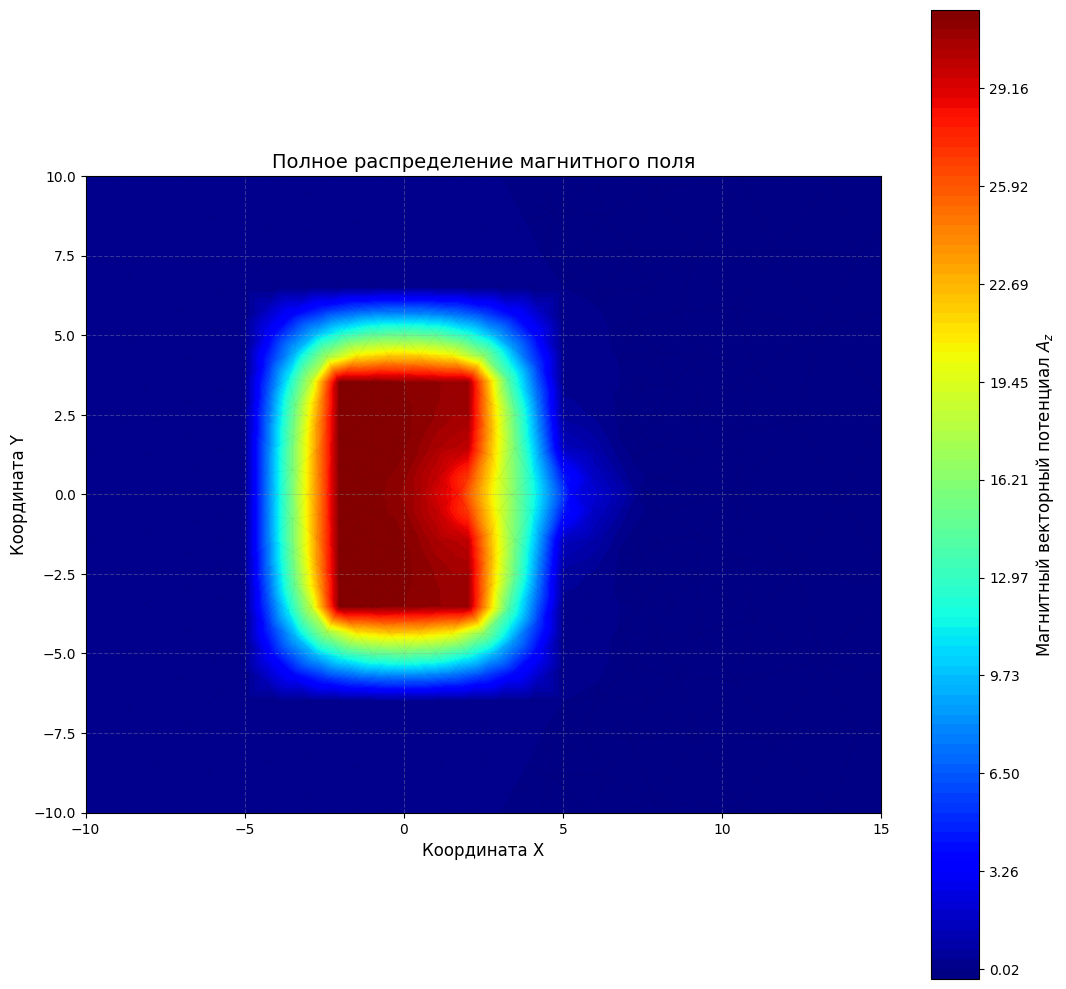

In [52]:
#объект триангуляции matplotlib

triangulation_top = tri.Triangulation(X_y[:, 0], X_y[:, 1], triangles)

triangulation_bottom = tri.Triangulation(X_y[:, 0], -X_y[:, 1], triangles)

plt.figure(figsize=(11, 10))
ax = plt.gca()
ax.set_aspect('equal')

vmin = u_fem_np.min()
vmax = u_fem_np.max()
levels = np.linspace(vmin, vmax, 100)

contour_top = ax.tricontourf(triangulation_top, u_fem_np, levels=levels, cmap='jet')
contour_bottom = ax.tricontourf(triangulation_bottom, u_fem_np, levels=levels, cmap='jet')

ax.triplot(triangulation_top, color='black', alpha=0.05, linewidth=0.5)
ax.triplot(triangulation_bottom, color='black', alpha=0.05, linewidth=0.5)

cbar = plt.colorbar(contour_top)
cbar.set_label('Магнитный векторный потенциал $A_z$', fontsize=12)

ax.set_xlim(-10, 15)
ax.set_ylim(-10, 10)

# ax.set_xlim(-55, 55)
# ax.set_ylim(-55, 55)

plt.title('Полное распределение магнитного поля', fontsize=14)
plt.xlabel('Координата X', fontsize=12)
plt.ylabel('Координата Y', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()